# Toivonen's Algorithm

## Learning Objectives

1. **Define** the negative border $B^-(S)$ of a frequent set family
2. **State** the key theorem: globally frequent itemsets cannot be in $B^-$
3. **Trace** the algorithm's two phases: sample mining and single full scan
4. **Explain** why a restart is needed when the theorem is violated
5. **Implement** negative border computation and Toivonen's full pipeline


## Problem Statement

### Motivation

A-Priori and PCY require 2+ passes over disk and can still be memory-heavy for candidate generation. SON still requires 2 full passes.

Toivonen's algorithm achieves a **single full pass** over the data (after an initial sample-based pass), with **no false negatives** — but it is **randomised**: with small probability it must restart.

### Key Idea

1. **Sample** $\approx \sqrt{n}$ baskets; mine frequent itemsets $F(S)$ at a reduced threshold $s/2$
2. Compute the **negative border** $B^-(S)$ — itemsets just outside $F(S)$ with all proper subsets in $F(S)$
3. Do **one full scan**: count every itemset in $F(S) \cup B^-(S)$
4. If any element of $B^-(S)$ turns out globally frequent → the sample missed it → **restart** with a larger sample (happens with low probability $\delta$)
5. Otherwise, return the globally frequent subset of $F(S)$


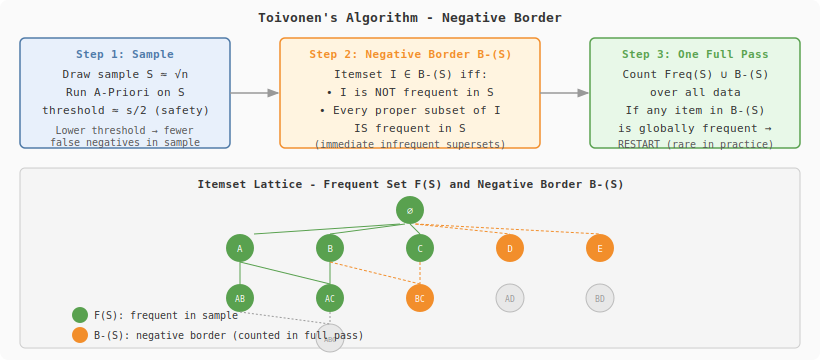

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="360" font-family="monospace" font-size="12">
  <rect width="820" height="360" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Toivonen's Algorithm  -  Negative Border</text>

  <!-- Sample + Apriori -->
  <rect x="20" y="38" width="210" height="110" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="125" y="58" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Step 1: Sample</text>
  <text x="125" y="78" text-anchor="middle" fill="#333" font-size="11">Draw sample S ≈ √n</text>
  <text x="125" y="96" text-anchor="middle" fill="#333" font-size="11">Run A-Priori on S</text>
  <text x="125" y="114" text-anchor="middle" fill="#333" font-size="11">threshold ≈ s/2 (safety)</text>
  <text x="125" y="134" text-anchor="middle" fill="#555" font-size="10">Lower threshold → fewer</text>
  <text x="125" y="146" text-anchor="middle" fill="#555" font-size="10">false negatives in sample</text>
  <line x1="230" y1="93" x2="278" y2="93" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- Negative border -->
  <rect x="280" y="38" width="260" height="110" rx="5" fill="#fff4e0" stroke="#f28e2b" stroke-width="1.5"/>
  <text x="410" y="58" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Step 2: Negative Border B-(S)</text>
  <text x="410" y="78" text-anchor="middle" fill="#333" font-size="11">Itemset I ∈ B-(S) iff:</text>
  <text x="410" y="96" text-anchor="middle" fill="#333" font-size="11">  • I is NOT frequent in S</text>
  <text x="410" y="114" text-anchor="middle" fill="#333" font-size="11">  • Every proper subset of I</text>
  <text x="410" y="132" text-anchor="middle" fill="#333" font-size="11">    IS frequent in S</text>
  <text x="410" y="148" text-anchor="middle" fill="#555" font-size="10">(immediate infrequent supersets)</text>
  <line x1="540" y1="93" x2="588" y2="93" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- Full scan -->
  <rect x="590" y="38" width="210" height="110" rx="5" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="695" y="58" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">Step 3: One Full Pass</text>
  <text x="695" y="78" text-anchor="middle" fill="#333" font-size="11">Count Freq(S) ∪ B-(S)</text>
  <text x="695" y="96" text-anchor="middle" fill="#333" font-size="11">over all data</text>
  <text x="695" y="114" text-anchor="middle" fill="#333" font-size="11">If any item in B-(S)</text>
  <text x="695" y="132" text-anchor="middle" fill="#333" font-size="11">is globally frequent →</text>
  <text x="695" y="148" text-anchor="middle" fill="#555" font-size="10">RESTART (rare in practice)</text>

  <!-- Lattice diagram -->
  <rect x="20" y="168" width="780" height="180" rx="5" fill="#f5f5f5" stroke="#ccc"/>
  <text x="410" y="188" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Itemset Lattice  -  Frequent Set F(S) and Negative Border B-(S)</text>
  <!-- ∅ -->
  <circle cx="410" cy="210" r="14" fill="#59a14f"/>
  <text x="410" y="214" text-anchor="middle" fill="white" font-size="10">∅</text>
  <!-- singletons -->
  <circle cx="240" cy="248" r="14" fill="#59a14f"/>
  <text x="240" y="252" text-anchor="middle" fill="white" font-size="9">A</text>
  <circle cx="330" cy="248" r="14" fill="#59a14f"/>
  <text x="330" y="252" text-anchor="middle" fill="white" font-size="9">B</text>
  <circle cx="420" cy="248" r="14" fill="#59a14f"/>
  <text x="420" y="252" text-anchor="middle" fill="white" font-size="9">C</text>
  <circle cx="510" cy="248" r="14" fill="#f28e2b"/>
  <text x="510" y="252" text-anchor="middle" fill="white" font-size="9">D</text>
  <circle cx="600" cy="248" r="14" fill="#f28e2b"/>
  <text x="600" y="252" text-anchor="middle" fill="white" font-size="9">E</text>
  <!-- pairs -->
  <circle cx="240" cy="298" r="14" fill="#59a14f"/>
  <text x="240" y="302" text-anchor="middle" fill="white" font-size="8">AB</text>
  <circle cx="330" cy="298" r="14" fill="#59a14f"/>
  <text x="330" y="302" text-anchor="middle" fill="white" font-size="8">AC</text>
  <circle cx="420" cy="298" r="14" fill="#f28e2b"/>
  <text x="420" y="302" text-anchor="middle" fill="white" font-size="8">BC</text>
  <circle cx="510" cy="298" r="14" fill="#e8e8e8" stroke="#bbb"/>
  <text x="510" y="302" text-anchor="middle" fill="#999" font-size="8">AD</text>
  <circle cx="600" cy="298" r="14" fill="#e8e8e8" stroke="#bbb"/>
  <text x="600" y="302" text-anchor="middle" fill="#999" font-size="8">BD</text>
  <!-- triple -->
  <circle cx="330" cy="338" r="14" fill="#e8e8e8" stroke="#bbb"/>
  <text x="330" y="342" text-anchor="middle" fill="#999" font-size="7">ABC</text>
  <!-- edges -->
  <line x1="400" y1="224" x2="254" y2="234" stroke="#59a14f" stroke-width="1"/>
  <line x1="405" y1="224" x2="330" y2="234" stroke="#59a14f" stroke-width="1"/>
  <line x1="410" y1="224" x2="420" y2="234" stroke="#59a14f" stroke-width="1"/>
  <line x1="415" y1="224" x2="510" y2="234" stroke="#f28e2b" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="416" y1="224" x2="600" y2="234" stroke="#f28e2b" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="240" y1="262" x2="240" y2="284" stroke="#59a14f" stroke-width="1"/>
  <line x1="240" y1="262" x2="330" y2="284" stroke="#59a14f" stroke-width="1"/>
  <line x1="330" y1="262" x2="330" y2="284" stroke="#59a14f" stroke-width="1"/>
  <line x1="330" y1="262" x2="420" y2="284" stroke="#f28e2b" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="420" y1="262" x2="420" y2="284" stroke="#f28e2b" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="240" y1="312" x2="330" y2="324" stroke="#999" stroke-width="1" stroke-dasharray="2,2"/>
  <line x1="330" y1="312" x2="330" y2="324" stroke="#999" stroke-width="1" stroke-dasharray="2,2"/>
  <!-- legend -->
  <circle cx="80" cy="315" r="8" fill="#59a14f"/>
  <text x="94" y="319" fill="#333" font-size="10">F(S): frequent in sample</text>
  <circle cx="80" cy="335" r="8" fill="#f28e2b"/>
  <text x="94" y="339" fill="#333" font-size="10">B-(S): negative border (counted in full pass)</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Negative Border

**Definition:** $B^-(S)$ is the set of itemsets that are (a) NOT in $F(S)$ but (b) every proper subset IS in $F(S)$.

Think of it as the "frontier" of the frequent set lattice — the first layer of infrequent itemsets.

**Key Theorem:** If all items in $B^-(S)$ are globally infrequent, then $F(S)$ is exactly the set of globally frequent itemsets.

**Proof:** Suppose $I$ is globally frequent but not in $F(S)$. By downward closure, all subsets of $I$ are globally frequent. Consider the minimal subset $J \subseteq I$ that is not in $F(S)$. Then all proper subsets of $J$ are in $F(S)$ (by minimality), so $J \in B^-(S)$. But $J$ is globally frequent — contradiction. $\square$

### Why Restart?

If $\exists J \in B^-(S)$ with global count $\geq s$, then there exists a globally frequent itemset not in $F(S) \cup B^-(S)$ — we cannot determine which itemsets are truly frequent from the current pass. We must restart.

With a sample of size $\Theta(\sqrt{n})$ and safety factor $\alpha$, the probability of restart is $O(1/\sqrt{n})$.

### Cost

- 1 sample pass (tiny)
- 1 full disk scan
- Total: essentially **1 pass** over data
- Complexity: $O(n + |\text{candidates}|)$


## Algorithm Steps

1. **Sample** $S$ of size $\approx \sqrt{n}$ from data; mine $F(S)$ with threshold $\lfloor s/2 \rfloor$
2. **Negative border:** $B^-(S) = \{I \notin F(S) : \forall J \subsetneq I, J \in F(S)\}$
3. **Full scan:** count support of all itemsets in $F(S) \cup B^-(S)$
4. **Restart check:** if any $J \in B^-(S)$ has global support $\geq s$ → restart with larger sample
5. **Output:** $\{I \in F(S) : \text{global count}(I) \geq s\}$


In [2]:
import random
from collections import defaultdict
from itertools import combinations


def apriori_sample(baskets, min_support):
    """A-Priori on an in-memory list of baskets."""
    # Pass 1: singletons
    counts = defaultdict(int)
    for b in baskets:
        for item in b:
            counts[frozenset([item])] += 1
    L = {fs: c for fs, c in counts.items() if c >= min_support}
    freq = dict(L)
    k = 2
    while L:
        prev = list(L.keys())
        candidates = set()
        for i in range(len(prev)):
            for j in range(i+1, len(prev)):
                u = prev[i] | prev[j]
                if len(u) == k:
                    if all(frozenset(s) in L for s in combinations(u, k-1)):
                        candidates.add(u)
        if not candidates:
            break
        counts = defaultdict(int)
        for b in baskets:
            for c in candidates:
                if c <= b:
                    counts[c] += 1
        L = {fs: cnt for fs, cnt in counts.items() if cnt >= min_support}
        freq.update(L)
        k += 1
    return freq


def negative_border(freq_sets):
    """
    Compute B-: itemsets NOT in freq_sets but all proper subsets ARE in freq_sets.
    """
    freq_frozen = set(freq_sets.keys())
    # Collect all items that appear in any frequent set
    all_items = set()
    for fs in freq_frozen:
        all_items |= fs

    border = set()
    # For each frequent set, extend by one item to form candidates for B-
    for fs in freq_frozen:
        for item in all_items - fs:
            candidate = fs | frozenset([item])
            if candidate in freq_frozen:
                continue
            # Check all proper subsets are frequent
            if all(frozenset(s) in freq_frozen for s in combinations(candidate, len(candidate)-1)):
                border.add(candidate)
    return border


def toivonen(all_baskets, global_support, sample_frac=0.1, safety_factor=0.5, seed=42):
    """
    Toivonen's Algorithm for frequent itemset mining.

    Inputs
    ------
    all_baskets    : list of sets (full dataset)
    global_support : int s  -  global frequency threshold
    sample_frac    : fraction of data to use as sample
    safety_factor  : lower threshold = safety_factor * (s * sample_frac)

    Returns
    -------
    dict {frozenset: int}  -  globally frequent itemsets, or None if restart needed
    """
    rng = random.Random(seed)
    n = len(all_baskets)
    sample_size = max(1, int(n * sample_frac))
    sample = rng.sample(all_baskets, sample_size)

    # Step 1: mine sample with reduced threshold
    local_support = max(1, int(global_support * sample_frac * safety_factor))
    freq_sample = apriori_sample(sample, local_support)

    # Step 2: compute negative border
    neg_border = negative_border(freq_sample)

    # Step 3: count F(S) ∪ B- on full dataset
    to_count = set(freq_sample.keys()) | neg_border
    global_counts = defaultdict(int)
    for basket in all_baskets:
        for itemset in to_count:
            if itemset <= basket:
                global_counts[itemset] += 1

    # Check: if any element of B- is globally frequent → restart
    for itemset in neg_border:
        if global_counts[itemset] >= global_support:
            print(f"RESTART needed: {set(itemset)} in B- is globally frequent (count={global_counts[itemset]})")
            return None  # in practice, re-run with larger sample

    # Return truly frequent itemsets
    return {fs: cnt for fs, cnt in global_counts.items()
            if fs in freq_sample and cnt >= global_support}


# ── Demo ──────────────────────────────────────────────────────────────────────
import random as rnd
rnd.seed(0)
items = list("ABCDEF")
baskets = [set(rnd.sample(items, rnd.randint(2, 4))) for _ in range(500)]

result = toivonen(baskets, global_support=80, sample_frac=0.15)
if result:
    print("Globally frequent itemsets (s=80):")
    for fs, cnt in sorted(result.items(), key=lambda x: (len(x[0]), -x[1])):
        print(f"  {str(set(fs)):<25}  support={cnt}")


Globally frequent itemsets (s=80):
  {'F'}                      support=261
  {'E'}                      support=255
  {'A'}                      support=248
  {'C'}                      support=247
  {'D'}                      support=244
  {'B'}                      support=233
  {'F', 'A'}                 support=127
  {'E', 'D'}                 support=118
  {'E', 'B'}                 support=116
  {'E', 'C'}                 support=115
  {'D', 'F'}                 support=114
  {'E', 'F'}                 support=114
  {'C', 'F'}                 support=113
  {'C', 'A'}                 support=108
  {'D', 'A'}                 support=108
  {'F', 'B'}                 support=108
  {'E', 'A'}                 support=106
  {'C', 'B'}                 support=101
  {'D', 'C'}                 support=100
  {'B', 'A'}                 support=96
  {'D', 'B'}                 support=95
